<a href="https://colab.research.google.com/github/arpitmathur16/Linear_regression_model/blob/main/Linear_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##What is Linear Regression?
It is a `supervised learning` algorithm used to predict a continuous numerical value (a target) based on one or more input variables (features).

It assumes a straight-line `relationship between the inputs and the output.` Think of it as finding the "best fit" line through your data points.

# Why does it exist?
It was developed to model and understand relationships between variables.
It helps us answer questions like: "If variable A increases by 10%, how much will variable B change?"

# Problem Statement
For this project, we want to solve a common educational challenge:

Goal: Predict a patient's Disease Progression based on their body metrics.
Business Value: By predicting which patients might get low scores, doctors can intervene early and provide extra medical attention.

# Import Libraries
Before starting, we need to load the standard Python libraries. We will use:



*   NumPy: For basic numerical lists.
*   Pandas: For working with data tables (DataFrames).
*   Matplotlib & Seaborn: For creating clean charts.
*   Scikit-Learn (sklearn): For building and evaluating   our Machine Learning model.







In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
from sklearn.datasets import load_diabetes
diabetes = load_diabetes(as_frame = True)
raw_df = diabetes.frame

df = pd.DataFrame({
    'BMI': raw_df['bmi'],
    'Blood_Pressure': raw_df['bp'],
    'Blood_Sugar_Level': raw_df['s6'],
    'Disease_Progression': raw_df['target']
})

print("Dataset Shape :" , df.shape)
print("---------------------------------")
print("First five rows of the Dataset")
print("          ")
print(df.head())
print("---------------------------------")
print("                  ")
print("Information of the Dataset")
print("                           ")
df.info()

Dataset Shape : (442, 4)
---------------------------------
First five rows of the Dataset
          
        BMI  Blood_Pressure  Blood_Sugar_Level  Disease_Progression
0  0.061696        0.021872          -0.017646                151.0
1 -0.051474       -0.026328          -0.092204                 75.0
2  0.044451       -0.005670          -0.025930                141.0
3 -0.011595       -0.036656          -0.009362                206.0
4 -0.036385        0.021872          -0.046641                135.0
---------------------------------
                  
Information of the Dataset
                           
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 4 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   BMI                  442 non-null    float64
 1   Blood_Pressure       442 non-null    float64
 2   Blood_Sugar_Level    442 non-null    float64
 3   Disease_Progression  442

### What Did We Observe?
* The dataset consists of **100 rows** (records) and **4 columns** (features + target).
* All columns contain numerical numbers (floats or integers).
* There are no missing text entries or NaN cells initially.

### What Did We Learn?
* Data is stored in a two-dimensional grid called a **DataFrame** using Pandas.
* We have 3 independent variables (features) and 1 dependent variable (the final score we want to predict).


# 5. Exploratory Data Analysis (EDA)

EDA is the process of examining the data visually to find patterns, anomalies, and correlations. Let's create three charts:
1. **Histogram of BMI** to understand the distribution of patient habits.
2. **Scatter plot of BMI vs. Disease Progression** to see their direct relationship.
3. **Correlation Heatmap** to see how all numeric variables relate to one another.


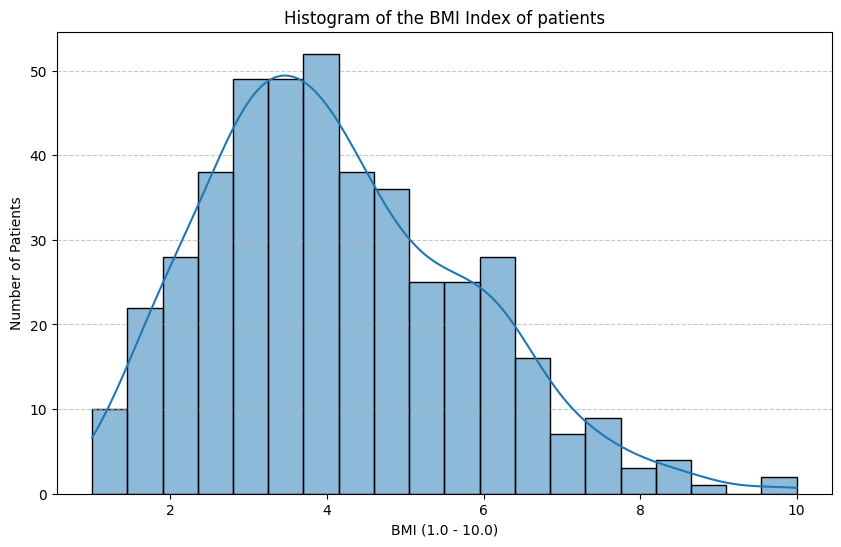

In [14]:
min_bmi_original = df['BMI'].min()
max_bmi_original = df['BMI'].max()

# Scale BMI to the target range [1, 10]
scaled_bmi = 1 + (df['BMI'] - min_bmi_original) * (10 - 1) / (max_bmi_original - min_bmi_original)

plt.figure(figsize=(10, 6))
sns.histplot(scaled_bmi, bins=20, kde=True)
plt.title('Histogram of the BMI Index of patients')
plt.xlabel('BMI (1.0 - 10.0)')
plt.ylabel('Number of Patients')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()